## 概要

解説記事「[D-Wave量子アニーラーを用いた制限ボルツマンマシンの学習](https://qard.is.tohoku.ac.jp/T-Wave/2026/03/25/d-wave%e9%87%8f%e5%ad%90%e3%82%a2%e3%83%8b%e3%83%bc%e3%83%a9%e3%83%bc%e3%82%92%e7%94%a8%e3%81%84%e3%81%9f%e5%88%b6%e9%99%90%e3%83%9c%e3%83%ab%e3%83%84%e3%83%9e%e3%83%b3%e3%83%9e%e3%82%b7%e3%83%b3/)」ではCD-1でサンプリングして学習されたRBMとQAからサンプリングして学習されたRBMを使って、BASデータセットの画像分類と画像再構成および対数尤度の性能を比較するという論文を紹介しました。本記事では、実際にアルゴリズムを実装し、元論文の再現実験を行います。今回はQAの代わりにシミュレーテッド・アニーリング(SA)を用いました。

## 文献情報



*   タイトル : Training Restricted Boltzmann Machines With a D-Wave Quantum Annealer
*   著者 : Vivek Dixit, Raja Selvarajan, Muhammad A. Alam, Travis S. Humble and Sabre Kais
*   書誌情報 : https://doi.org/10.3389/fphy.2021.589626



## 準備

### ライブラリのインストールとインポート

In [ ]:
!pip install openjij

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 13.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import openjij as oj
import itertools
from scipy.special import logsumexp

### BASデータセットの準備

#### BASデータの作成

横縞のデータ(Bars)と縦縞のデータ(Stripes)から成るBASデータセットを作成します。画像のサイズは64ビットにし、最後の2ビットを画像分類の判定に使うため、横縞の時は01、縦縞の時は10のラベルを付けます。256枚のBarsと256枚のStripesの計512枚のデータセットが作成されます。

In [ ]:
def generate_bas_dataset():
    #画像のサイズ
    size = 8

    # 全ての 8ビットのパターンを生成(256通り)
    all_patterns = list(itertools.product([0, 1], repeat=size))
    all_patterns = np.array(all_patterns)

    dataset = []

    # Bars (横縞) の生成(各行が同じ値を持つパターン)
    for pat in all_patterns:

        # 行ごとにON/OFFが決まる
        #patは一次元配列、pat.reshape(-1, 1)で縦ベクトルの2次元配列(8, 1)を作成
        #np.tileで同じタイルを敷き詰める。(1, size=8)より縦方向に8回同じものをコピーして並べる。
        img = np.tile(pat.reshape(-1, 1), (1, size))

        # フラット化して1次元配列 (64ビット) にする
        flat_img = img.flatten()

        # 64ビット画像から先頭62ビットを取得（実質的に最後の2ピクセルを削除）
        input_bits = flat_img[:62]

        # ラベルBars = 01
        label = np.array([0, 1])

        # 62ビットのデータ + 2ビットのラベル
        record = np.concatenate([input_bits, label])
        dataset.append(record)

    # Stripes (縦縞) の生成(各列が同じ値を持つパターン)
    for pat in all_patterns:

        img = np.tile(pat.reshape(1, -1), (size, 1))

        flat_img = img.flatten()

        input_bits = flat_img[:62]

        # ラベルStripes = 10
        label = np.array([1, 0])

        record = np.concatenate([input_bits, label])
        dataset.append(record)

    return np.array(dataset)

#### BASデータの確認

正しくBASデータが作成されているか確認するために、データセットからランダムに5枚、画像として可視化します。

In [ ]:
def visualize_samples(dataset, num_samples=5):

    # ランダムにサンプル抽出
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

    for i, idx in enumerate(indices):
        record = dataset[idx]

        # 最後の2ビットはラベル
        label_bits = record[-2:]
        if np.array_equal(label_bits, [0, 1]):
            label_name = "Bar (01)"
        elif np.array_equal(label_bits, [1, 0]):
            label_name = "Stripe (10)"
        else:
            label_name = "Unknown"

        # ラベル付きのBASデータの画像
        img_reconstructed = record.reshape(8, 8)

        axes[i].imshow(img_reconstructed, cmap='cividis') # 論文の黄色・青に近い色味
        axes[i].set_title(f"Idx: {idx}\n{label_name}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

画像を可視化します。黄色が1に、黒が0に対応します。画像の右下が01の時に横縞となり、10の時に縦縞となる様子が確認できます。

データセット形状: (512, 64)
内訳: Bars 256個 + Stripes 256個


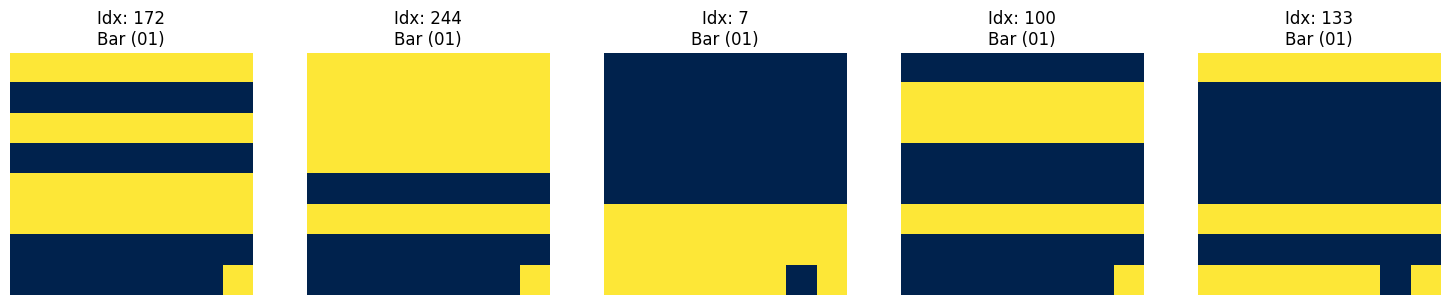

In [ ]:
bas_dataset = generate_bas_dataset()

print(f"データセット形状: {bas_dataset.shape}") # 期待値: (512, 64)
print(f"内訳: Bars 256個 + Stripes 256個")

# データの可視化
visualize_samples(bas_dataset)

### RBMの実装

#### RBMの基本の実装

In [ ]:
def __init__(self, n_visible, n_hidden, learning_rate=0.05):
    """
    n_visible: 可視層のユニット数
    n_hidden: 隠れ層のユニット数
    learning_rate: 学習率
    W: 重み行列(0付近の値で初期化)
    b: 可視層のバイアス(0で初期化)
    c: 隠れ層のバイアス(0で初期化)
    """
    self.n_visible = n_visible
    self.n_hidden = n_hidden
    self.lr = learning_rate
    self.W = np.random.normal(0, 0.01, (n_visible, n_hidden))
    self.b = np.zeros(n_visible)
    self.c = np.zeros(n_hidden)

    # 実験1、実験3でエポック毎の正解率と対数尤度をもとめるために保存用のリストを作る
    self.history = {'bars_acc': [], 'stripes_acc': [], 'll': []}

# シグモイド関数
def sigmoid(self, x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

# 可視層の状態から隠れ層の値をサンプリングする関数
def sample_h_given_v(self, v):
    # 隠れ層のユニットが1になる確率を可視層の値を基に計算
    prob_h = self.sigmoid(np.dot(v, self.W) + self.c)
    # 0以上1以下の一様分布に従う乱数を生成し、prob_hのユニット毎の値と比較して0か1を決める
    h_sample = (np.random.rand(*prob_h.shape) < prob_h).astype(float)
    return prob_h, h_sample

# 隠れ層の状態から可視層の値をサンプリングする関数
def sample_v_given_h(self, h):
    prob_v = self.sigmoid(np.dot(h, self.W.T) + self.b)
    v_sample = (np.random.rand(*prob_v.shape) < prob_v).astype(float)
    return prob_v, v_sample

RBMの学習では重みとバイアスを更新するために式(1)、(2)、(3)を計算します。(詳細は[解説記事](https://qard.is.tohoku.ac.jp/T-Wave/2026/03/25/d-wave%e9%87%8f%e5%ad%90%e3%82%a2%e3%83%8b%e3%83%bc%e3%83%a9%e3%83%bc%e3%82%92%e7%94%a8%e3%81%84%e3%81%9f%e5%88%b6%e9%99%90%e3%83%9c%e3%83%ab%e3%83%84%e3%83%9e%e3%83%b3%e3%83%9e%e3%82%b7%e3%83%b3/)と[用語集](https://qard.is.tohoku.ac.jp/T-Wave/2026/03/25/%e3%83%9c%e3%83%ab%e3%83%84%e3%83%9e%e3%83%b3%e3%83%9e%e3%82%b7%e3%83%b3%e3%81%a8%e5%88%b6%e9%99%90%e3%83%9c%e3%83%ab%e3%83%84%e3%83%9e%e3%83%b3%e3%83%9e%e3%82%b7%e3%83%b3/)をご覧ください。) 期待値$\mathbb{E}_{P_\theta(\vec{V},\vec{H})}[⋅]$の厳密計算は困難であるため、モデル分布からサンプルを生成し、サンプル平均によって近似します。

$$ W_{ij} \leftarrow W_{ij} + \eta \left( \mathbb{E}_{P_{\text{data}}(\vec{v})P_\theta(\vec{h}\mid \vec{v})}[v_i h_j] - \mathbb{E}_{P_\theta(\vec{V},\vec{H})}[v_i h_j] \right) \tag{1} $$

$$ b_i \leftarrow b_i + \eta \left( \mathbb{E}_{P_{\text{data}}(\vec{v})P_\theta(\vec{h}\mid \vec{v})}[v_i] - \mathbb{E}_{P_\theta(\vec{V},\vec{H})}[v_i] \right) \tag{2}$$

$$ c_j \leftarrow c_j + \eta \left( \mathbb{E}_{P_{\text{data}}(\vec{v})P_\theta(\vec{h}\mid \vec{v})}[h_j] - \mathbb{E}_{P_\theta(\vec{V},\vec{H})}[h_j] \right) \tag{3}$$

論文では期待値$\mathbb{E}_{P_\theta(\vec{V},\vec{H})}[⋅]$の計算に2通りのサンプリング方法を用いています。一つは、コントラスティブ・ダイバージェンス(CD)というよく使われる方法で、もう一つは量子アニーラーからサンプリングする方法です。(詳細は[解説記事](https://qard.is.tohoku.ac.jp/T-Wave/2026/03/25/d-wave%e9%87%8f%e5%ad%90%e3%82%a2%e3%83%8b%e3%83%bc%e3%83%a9%e3%83%bc%e3%82%92%e7%94%a8%e3%81%84%e3%81%9f%e5%88%b6%e9%99%90%e3%83%9c%e3%83%ab%e3%83%84%e3%83%9e%e3%83%b3%e3%83%9e%e3%82%b7%e3%83%b3/)と[用語集](https://qard.is.tohoku.ac.jp/T-Wave/2026/03/25/%e3%83%9c%e3%83%ab%e3%83%84%e3%83%9e%e3%83%b3%e3%83%9e%e3%82%b7%e3%83%b3%e3%81%a8%e5%88%b6%e9%99%90%e3%83%9c%e3%83%ab%e3%83%84%e3%83%9e%e3%83%b3%e3%83%9e%e3%82%b7%e3%83%b3/)をご覧ください。)

#### CD-1のサンプリングによるRBMの学習関数の実装

まず、訓練データの一つ$\vec{v}^{(0)}$を可視層に入力します。次に式(4)で表される確率に従って、隠れ層の値$\vec{h}^{(0)}$を決めます。この時、確率を基に決めているので、値は一意には決まりません。

$$P(H_j = 1 \mid \vec{v}^{(0)}) = \sigma \left(b_i+\sum_i W_{ij} v_i^{(0)}\right) \tag{4}$$

次に、得られた隠れユニットから式(5)に従って、可視層の値$\vec{v}^{(1)}$を決めます。

$$P(V_i = 1 \mid \vec{h}^{(0)}) = \sigma \left(c_i+\sum_j W_{ij} h_j^{(0)}\right) \tag{5}$$

さらに、もう一度隠れ層の値$\vec{h}^{(1)}$をサンプリングします。

$$P(H_j = 1 \mid \vec{v}^{(1)}) = \sigma \left(b_i+\sum_i W_{ij} v_i^{(1)}\right) \tag{6}$$

In [ ]:
def train_step_cd(self, batch):
    n_batch = batch.shape[0]
    # 可視層には訓練データを入力
    pos_v = batch
    prob_h0, pos_h = self.sample_h_given_v(pos_v) # 式(4)
    _, neg_v = self.sample_v_given_h(pos_h) # 式(5)
    prob_h1, _ = self.sample_h_given_v(neg_v) # 式(6)

    self.W += self.lr * (np.dot(pos_v.T, prob_h0) - np.dot(neg_v.T, prob_h1)) / n_batch # 式(1)
    self.b += self.lr * np.mean(pos_v - neg_v, axis=0) # 式(2)
    self.c += self.lr * np.mean(prob_h0 - prob_h1, axis=0) # 式(3)

#### SAのサンプリングによるRBMの学習関数の実装

QAによる計算を模したシミュレーテッド・アニーリング(SA)で実装します。具体的にはOpenJijのSAsamplerを使ってサンプリングします。サンプリングの方法はQAと同じです。


1.   QUBOを作る
2.   サンプリングする
3.   勾配を計算する
4.   QUBOを更新する
5.   1.～4.を値が収束するまで行う

QAは式(7)を基に作られたQUBOを使って、エネルギー$E_\theta(\vec{v},\vec{h})$を最小にします。

$$ E_\theta(\vec{v},\vec{h}) = -\sum_{i=1}^{n} b_i v_i -\sum_{j=1}^{m} c_j h_j -\sum_{i=1}^{n}\sum_{j=1}^{m} v_i W_{ij} h_j \tag{7} $$

QUBOは上三角行列です。対角成分は可視バイアス(ノード数$n$)と隠れバイアス(ノード数$m$)であり、その他は重みを表します。train_step_sa関数を呼び出す毎に更新されたパラメータを使ってQUBOが作成し直されます。

SAでは、高い温度(beta_min)から低い温度(beta_max)に変化させながら、エネルギーが最小となる$v_i$と$h_j$の値を探索していきます。この時、num_sweepsはどのくらいの程度で温度を下げていくかを示し、num_readsは何回SAを行うかを示します。num_sweepsの値が大きいと、ゆっくりと温度が下がるため、最適解が見つかりやすく、num_readsの値が大きいと、サンプルが増えるので、平均すると真の確率分布に近づきます。
今回の実験では

*   beta_min=0.2
*   beta_max=1.0
*   num_reads=16
*   num_sweeps=100

と設定しました。

In [ ]:
def train_step_sa(self, batch, num_reads, num_sweeps=100):
    n_batch = batch.shape[0]
    pos_v = batch
    prob_h0, _ = self.sample_h_given_v(pos_v)

    sampler = oj.SASampler()
    qubo = {}
    for i in range(self.n_visible): qubo[(i, i)] = -self.b[i] # 対角成分に可視バイアスを代入
    for j in range(self.n_hidden): qubo[(self.n_visible+j, self.n_visible+j)] = -self.c[j] # 対角成分に隠れバイアスを代入
    for i in range(self.n_visible):
        for j in range(self.n_hidden): qubo[(i, self.n_visible+j)] = -self.W[i, j] # 対角成分より上側に重みを代入

    response = sampler.sample_qubo(qubo, num_reads=num_reads, num_sweeps=num_sweeps, beta_min=0.2, beta_max=1.0)
    neg_v = response.record.sample[:, :self.n_visible].astype(float)
    prob_h_model, _ = self.sample_h_given_v(neg_v)

    # パラメータをサンプル数で割って平均化する
    self.W += self.lr * (np.dot(pos_v.T, prob_h0) - np.dot(neg_v.T, prob_h_model)) / num_reads # 重みを平均化
    self.b += self.lr * (np.mean(pos_v, axis=0) - np.mean(neg_v, axis=0)) # 可視バイアスを平均化
    self.c += self.lr * (np.mean(prob_h0, axis=0) - np.mean(prob_h_model, axis=0)) # 隠れバイアスを平均化

#### 画像分類の正解率をもとめる関数

実験1で使用するために、RBMによる画像分類の正解率をもとめる関数を実装します。ここではテストデータのラベルをランダムに初期化し、RBMでラベルを判定させます。その際、学習したRBMで再度ギブスサンプリングを50回行った後に、ラベルを読み取ります。その後、正解ラベルと比較して正解率を計算します。

In [ ]:
def get_accuracy(self, test_subset, gibbs_steps=50):
    if len(test_subset) == 0: return 0.0
    correct = 0
    for rec in test_subset:
        true_label = rec[62:]
        v_curr = np.concatenate([rec[:62], np.random.randint(0, 2, size=2)])
        for _ in range(gibbs_steps):
            _, h_s = self.sample_h_given_v(v_curr)
            _, v_s = self.sample_v_given_h(h_s)
            v_curr[62:] = v_s[62:] # Label部分のみ更新
        if np.array_equal(v_curr[62:], true_label): correct += 1
    return correct / len(test_subset)

#### 画像再構成する関数

実験2の準備として、指定した範囲のビットをランダムな0と1の配列にして破損させた画像を再構成する関数を実装します。この関数では、破損させた画像(ただし、ラベルの2ビットは除く)をRBM学習器にセットして50回ギブスサンプリングを行った値を返します。

In [ ]:
def reconstruct_image(self, original_vector, mask_indices, gibbs_steps=50):
    """
    指定したインデックスを破損させ、RBM学習器で復元する
    original_vector: 元の画像のビット配列
    mask_indices: 破損させるビットを示すインデックスの配列
    gibbs_steps: ギブスサンプリングのステップ数
    """
    corrupted_vector = original_vector.copy()
    # 破損部分を0と1でランダムに埋める
    noise = np.random.randint(0, 2, size=len(mask_indices))
    corrupted_vector[mask_indices] = noise

    v_curr = corrupted_vector.copy()
    all_indices = np.arange(len(original_vector))

    # np.setdiff1d(配列A, 配列B): 配列Aから配列Bに含まれる要素を除いたもの
    fixed_indices = np.setdiff1d(all_indices, mask_indices)

    for _ in range(gibbs_steps):
        _, h_s = self.sample_h_given_v(v_curr)
        _, v_s = self.sample_v_given_h(h_s)

        # 固定するビット
        v_curr[fixed_indices] = original_vector[fixed_indices]
        v_curr[mask_indices] = v_s[mask_indices]

    return corrupted_vector, v_curr

#### 画像再構成のエラー数をもとめる関数

また、再構成した画像と元画像を比較した時、どのくらいの異なるビットがあるか計算する関数を実装します。

In [ ]:
def get_incorrect_bits(self, dataset, mask_indices, gibbs_steps=50):
    """
    データセットに対し、破損された領域の再構成エラー（誤ビット数）を計算する
    """
    error_list = []
    for original_vector in dataset:
        # 再構成を実行
        _, restored_vector = self.reconstruct_image(original_vector, mask_indices, gibbs_steps)

        # 破損された範囲のビット列において、正解値と再構成後の値を比較
        actual = original_vector[mask_indices] # 正解値
        predicted = restored_vector[mask_indices] # 再構成後の値

        # 異なるビットの数をカウント
        incorrect_count = np.sum(actual != predicted)
        error_list.append(incorrect_count)

    return np.array(error_list)

#### 対数尤度をもとめる関数

実験3の準備として、RBMの対数尤度を計算する関数を実装します。可視層$v$を周辺化して、隠れ層$h$のすべての和をとるという手段で計算します。

具体的な計算方法を説明します。

$$\begin{align}\log P(v) &= \log \frac{\sum_h e^{-E(v, h)}}{Z}\\ &= \log (\sum_h e^{-E(v, h)}) - \log Z \tag{8} \end{align}$$

式(1)では対数尤度は2つの項の差で表されます。まず、式(2)で可視層と隠れ層の和の部分に分けます。$s = b^T + h^TW$としました。

$$\begin{align} Z &= \sum_{v} \sum_{h} e^{b^Tv + c^Th + h^TWv}\\ &= \sum_h e^{c^Th} \sum_v e^{(b^T + h^TW)v}\\ &= \sum_{h \in \lbrace 0, 1 \rbrace ^m} e^{c^T h} \sum_{v \in \lbrace 0, 1 \rbrace ^n} e^{s \cdot v} \tag{9} \end{align}$$

次に可視層に関する和について、RBMでは同じ層内で結合がないことを利用して、指数の積で表すことができます。(式(3))

$$\begin{align} \sum_{v \in \lbrace 0, 1 \rbrace ^n} e^{s \cdot v} &= \sum_{v_1 \in \lbrace 0, 1 \rbrace} e^{s_1 v_1} \cdots \sum_{v_n \in \lbrace 0, 1 \rbrace} e^{s_n v_n}\\ &= \prod_{i=1}^n \sum_{v_i \in \lbrace 0, 1 \rbrace} e^{s_i v_i}\\ &= \prod_{i=1}^n (1 + e^{s_i}) \tag{10} \end{align}$$

式(3)を式(2)に代入して、可視層$v$を周辺化します。これにより、隠れ層$h$のすべての状態の和がもとまれば、式(4)で計算できるようになりました。

$$\begin{align}\log Z &= \log (\sum_{h \in \lbrace 0, 1 \rbrace ^m} e^{c^T h} \prod_{i=1}^n (1 + e^{s_i}))\\ &= \log (\sum_{h \in \lbrace 0, 1 \rbrace ^m} e^{c^T h + \sum_{i = 1}^n \log (1 + e^{s_i})}) \tag{11} \end{align}$$

同様に、前半の項についてもRBMの性質を利用して式(5)のように表せます。

$$ \log (\sum_h e^{-E(v,h)})
= b^T v + \sum_{j=1}^{m} \log \left(1 + e^{c_j + \sum_{i=1}^{n} W_{ij}v_i} \right) \tag{12} $$

このように、対数尤度は式(4)と式(5)から計算することができます。

In [ ]:
def get_log_likelihood(self, data, all_hidden_states):
    # 分配関数 Z の計算
    term_h = np.dot(all_hidden_states, self.c)
    vis_act = self.b + np.dot(all_hidden_states, self.W.T)
    # logaddexp(x, y) = log(e^x + e^y)
    log_Z = logsumexp(term_h + np.sum(np.logaddexp(0, vis_act), axis=1))

    # 非正規化尤度の計算
    data_term = np.dot(data, self.b)
    hid_act = self.c + np.dot(data, self.W)
    log_unnorm = data_term + np.sum(np.logaddexp(0, hid_act), axis=1)

    return np.mean(log_unnorm - log_Z)

### クラスによる統合

これまでの関数を一つのクラスにまとめて、扱いやすくします。

In [ ]:
class IntegratedRBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.05):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.lr = learning_rate
        self.W = np.random.normal(0, 0.01, (n_visible, n_hidden))
        self.b = np.zeros(n_visible)
        self.c = np.zeros(n_hidden)

        # 履歴保存用：bars正解率、stripes正解率、対数尤度
        self.history = {'bars_acc': [], 'stripes_acc': [], 'll': []}

    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def sample_h_given_v(self, v):
        prob_h = self.sigmoid(np.dot(v, self.W) + self.c)
        h_sample = (np.random.rand(*prob_h.shape) < prob_h).astype(float)
        return prob_h, h_sample

    def sample_v_given_h(self, h):
        prob_v = self.sigmoid(np.dot(h, self.W.T) + self.b)
        v_sample = (np.random.rand(*prob_v.shape) < prob_v).astype(float)
        return prob_v, v_sample

    # CD-1のサンプリングによる学習
    def train_step_cd(self, batch):
        n_batch = batch.shape[0]
        pos_v = batch
        prob_h0, pos_h = self.sample_h_given_v(pos_v)
        _, neg_v = self.sample_v_given_h(pos_h)
        prob_h1, _ = self.sample_h_given_v(neg_v)

        self.W += self.lr * (np.dot(pos_v.T, prob_h0) - np.dot(neg_v.T, prob_h1)) / n_batch
        self.b += self.lr * np.mean(pos_v - neg_v, axis=0)
        self.c += self.lr * np.mean(prob_h0 - prob_h1, axis=0)

    # SAのサンプリングによる学習
    def train_step_sa(self, batch, num_reads, num_sweeps=100):
        n_batch = batch.shape[0]
        pos_v = batch
        prob_h0, _ = self.sample_h_given_v(pos_v)

        sampler = oj.SASampler()
        qubo = {}
        for i in range(self.n_visible): qubo[(i, i)] = -self.b[i]
        for j in range(self.n_hidden): qubo[(self.n_visible+j, self.n_visible+j)] = -self.c[j]
        for i in range(self.n_visible):
            for j in range(self.n_hidden): qubo[(i, self.n_visible+j)] = -self.W[i, j]

        response = sampler.sample_qubo(qubo, num_reads=num_reads, num_sweeps=num_sweeps, beta_min=0.2, beta_max=1.0)
        neg_v = response.record.sample[:, :self.n_visible].astype(float)
        prob_h_model, _ = self.sample_h_given_v(neg_v)

        self.W += self.lr * (np.dot(pos_v.T, prob_h0) - np.dot(neg_v.T, prob_h_model)) / num_reads
        self.b += self.lr * (np.mean(pos_v, axis=0) - np.mean(neg_v, axis=0))
        self.c += self.lr * (np.mean(prob_h0, axis=0) - np.mean(prob_h_model, axis=0))

    # 画像分類の正解率
    def get_accuracy(self, test_subset, gibbs_steps=50):
        if len(test_subset) == 0: return 0.0
        correct = 0
        for rec in test_subset:
            true_label = rec[62:]
            v_curr = np.concatenate([rec[:62], np.random.randint(0, 2, size=2)])
            for _ in range(gibbs_steps):
                _, h_s = self.sample_h_given_v(v_curr)
                _, v_s = self.sample_v_given_h(h_s)
                v_curr[62:] = v_s[62:]
            if np.array_equal(v_curr[62:], true_label): correct += 1
        return correct / len(test_subset)

    # 画像再構成
    def reconstruct_image(self, original_vector, mask_indices, gibbs_steps=50):

        corrupted_vector = original_vector.copy()

        noise = np.random.randint(0, 2, size=len(mask_indices))
        corrupted_vector[mask_indices] = noise

        v_curr = corrupted_vector.copy()
        all_indices = np.arange(len(original_vector))
        fixed_indices = np.setdiff1d(all_indices, mask_indices)

        for _ in range(gibbs_steps):
            _, h_s = self.sample_h_given_v(v_curr)
            _, v_s = self.sample_v_given_h(h_s)

            v_curr[fixed_indices] = original_vector[fixed_indices]
            v_curr[mask_indices] = v_s[mask_indices]

        return corrupted_vector, v_curr

    # 画像再構成のエラー数
    def get_incorrect_bits(self, dataset, mask_indices, gibbs_steps=50):

        error_list = []
        for original_vector in dataset:
            _, restored_vector = self.reconstruct_image(original_vector, mask_indices, gibbs_steps)

            actual = original_vector[mask_indices]
            predicted = restored_vector[mask_indices]

            incorrect_count = np.sum(actual != predicted)
            error_list.append(incorrect_count)

        return np.array(error_list)

    # 対数尤度
    def get_log_likelihood(self, data, all_hidden_states):

        term_h = np.dot(all_hidden_states, self.c)
        vis_act = self.b + np.dot(all_hidden_states, self.W.T)
        log_Z = logsumexp(term_h + np.sum(np.logaddexp(0, vis_act), axis=1))

        data_term = np.dot(data, self.b)
        hid_act = self.c + np.dot(data, self.W)
        log_unnorm = data_term + np.sum(np.logaddexp(0, hid_act), axis=1)

        return np.mean(log_unnorm - log_Z)

## 実験

### データ設定

2つのRBM学習器を訓練データで学習させて、テストデータで評価します。データセット512枚の内、400枚を訓練データとして、112枚をテストデータとして扱います。訓練データとテストデータに含まれるBarsとStripesの割合は等しいようにします。

In [ ]:
# データセットの生成
dataset = generate_bas_dataset()

# ラベルごとにデータを分ける
# Label: Bars=[0,1], Stripes=[1,0]
all_bars = dataset[(dataset[:, 62] == 0) & (dataset[:, 63] == 1)]
all_stripes = dataset[(dataset[:, 62] == 1) & (dataset[:, 63] == 0)]

# それぞれのデータセットをシャッフル
np.random.shuffle(all_bars)
np.random.shuffle(all_stripes)

# 訓練データに割り当てる数を決める
n_train_per_class = 200

# 各データセットから200個ずつ訓練データへ、残りをテストデータへ
train_bars = all_bars[:n_train_per_class]
test_bars = all_bars[n_train_per_class:]

train_stripes = all_stripes[:n_train_per_class]
test_stripes = all_stripes[n_train_per_class:]

# 訓練データとテストデータを結合して、さらに全体をシャッフル
train_data = np.concatenate([train_bars, train_stripes])
test_data = np.concatenate([test_bars, test_stripes])

np.random.shuffle(train_data)
np.random.shuffle(test_data)

# 結果の確認
print(f"Train Set: Bars={len(train_bars)}, Stripes={len(train_stripes)} (Total: {len(train_data)})")
print(f"Test Set: Bars={len(test_bars)}, Stripes={len(test_stripes)} (Total: {len(test_data)})")

Train Set: Bars=200, Stripes=200 (Total: 400)
Test Set: Bars=56, Stripes=56 (Total: 112)


### 実験1 : 画像分類

では実際にRBMを学習して画像分類を行います。可視層のノードを64、隠れ層のノードを64に設定します。学習率は0.10でバッチサイズは64にします。エポック数を400にして学習させます。

In [ ]:
"""
epochs: 学習回数
batch_size: バッチサイズ
rbm_cd: CD-1のサンプリングによる学習器
rbm_sa: SAのサンプリングによる学習器
"""

# モデルの初期化
epochs = 400
batch_size = 64
rbm_cd = IntegratedRBM(64, 64, learning_rate=0.10)
rbm_sa = IntegratedRBM(64, 64, learning_rate=0.10)

print("Training starting...")
for epoch in range(1, epochs + 1):
    np.random.shuffle(train_data)
    for i in range(0, len(train_data), batch_size):
        batch = train_data[i:i+batch_size]
        rbm_cd.train_step_cd(batch)
        rbm_sa.train_step_sa(batch, num_reads=batch_size)

    # エポック毎に正解率を記録
    rbm_cd.history['bars_acc'].append(rbm_cd.get_accuracy(test_bars))
    rbm_cd.history['stripes_acc'].append(rbm_cd.get_accuracy(test_stripes))
    rbm_sa.history['bars_acc'].append(rbm_sa.get_accuracy(test_bars))
    rbm_sa.history['stripes_acc'].append(rbm_sa.get_accuracy(test_stripes))

    if epoch % 50 == 0:
        print(f"Epoch {epoch} completed.")

Training starting...
Epoch 50 completed.
Epoch 100 completed.
Epoch 150 completed.
Epoch 200 completed.
Epoch 250 completed.
Epoch 300 completed.
Epoch 350 completed.
Epoch 400 completed.


CD-1学習のRBMとSA学習のRBMについて、BarsとStripesのエポック毎の正解率を描写します。

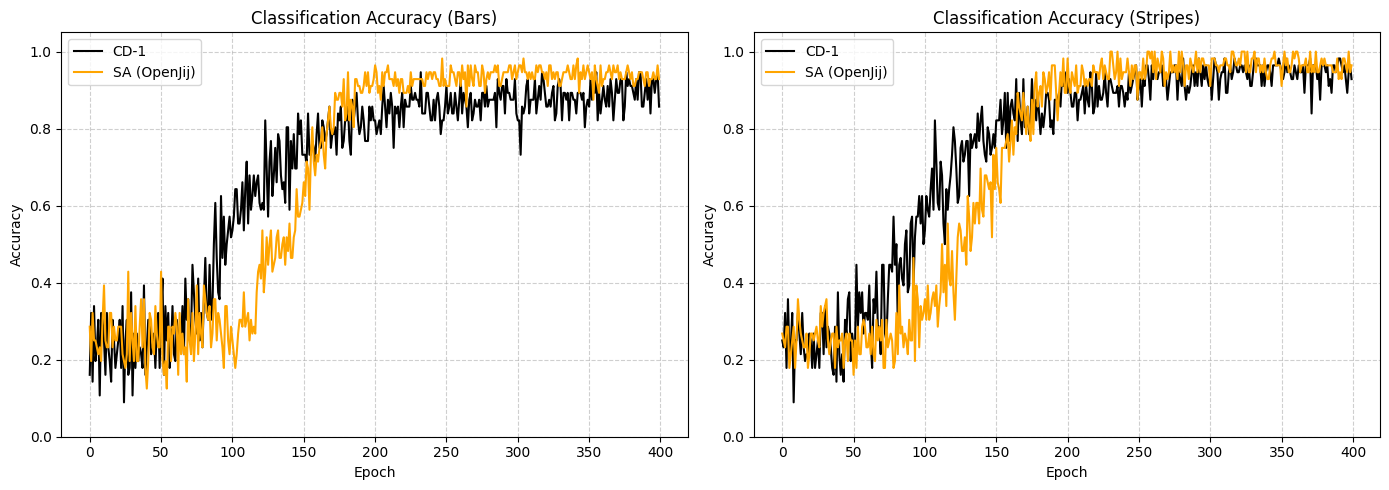

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barsの正解率
axes[0].plot(range(epochs), rbm_cd.history['bars_acc'], label='CD-1', color='black')
axes[0].plot(range(epochs), rbm_sa.history['bars_acc'], label='SA (OpenJij)', color='orange')
axes[0].set_title('Classification Accuracy (Bars)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.6)

# Stripesの正解率
axes[1].plot(range(epochs), rbm_cd.history['stripes_acc'], label='CD-1', color='black')
axes[1].plot(range(epochs), rbm_sa.history['stripes_acc'], label='SA (OpenJij)', color='orange')
axes[1].set_title('Classification Accuracy (Stripes)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 実験2 画像再構成

#### 画像再構成の結果

次のケースA、B、Cについて画像再構成を行った時、再構成された画像を比較します。

ケースA: ラベル(2ビット)を破損させた場合

ケースB: 画像の右下4×4(16ビット)を破損させた場合

ケースC: すべての画像(64ビット)を破損させた場合

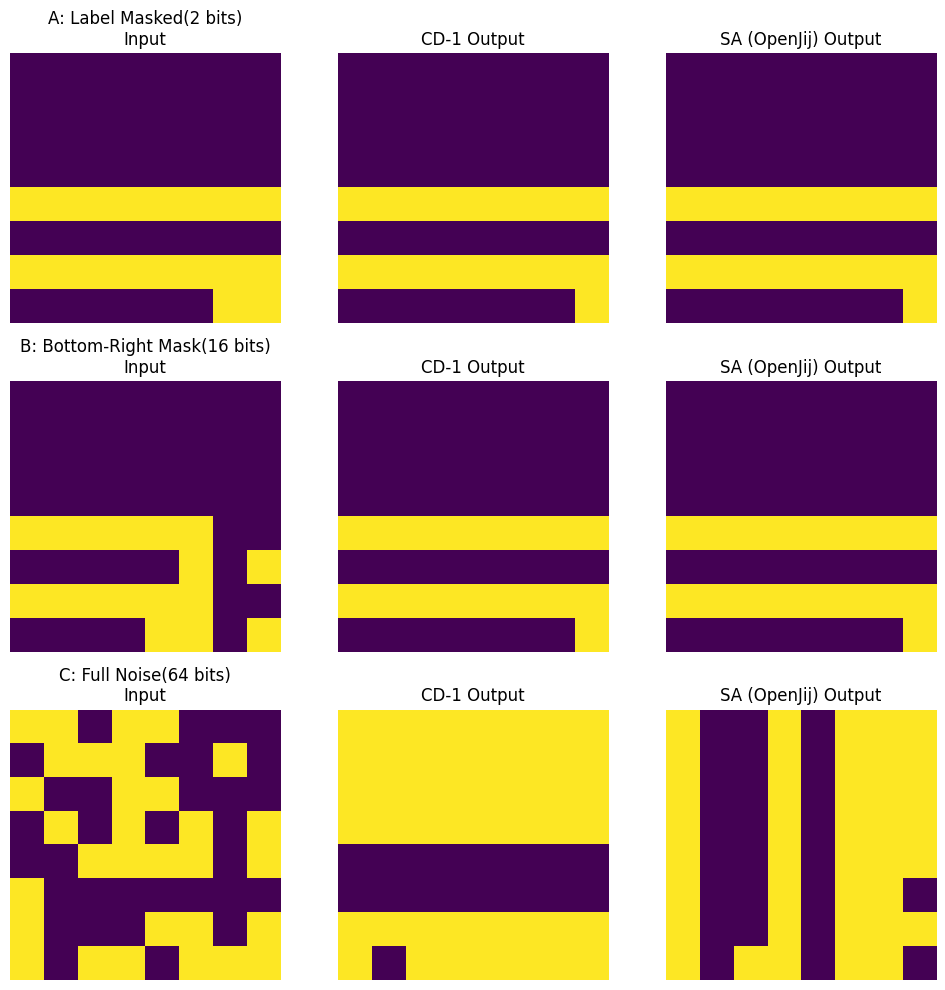

In [ ]:
# サンプル画像の用意
sample_bar = dataset[10]      # Barパターン
sample_stripe = dataset[-46]  # Stripeパターン

# ケースA: ラベルの破損
mask_A = [62, 63]
target_A = sample_bar.copy()
# target_A = sample_stripe.copy()
# クラスメソッドとして呼び出し
corp_A, cd_res_A = rbm_cd.reconstruct_image(target_A, mask_A)
_, sa_res_A      = rbm_sa.reconstruct_image(target_A, mask_A)

# ケースB: 右下4×4(16ビット)の破損
mask_B = []
for r in range(4, 8):
    for c in range(4, 8):
        mask_B.append(r * 8 + c)
mask_B = np.array(mask_B)

target_B = sample_bar.copy()
# target_B = sample_stripe.copy()
corp_B, cd_res_B = rbm_cd.reconstruct_image(target_B, mask_B)
_, sa_res_B      = rbm_sa.reconstruct_image(target_B, mask_B)

# ケースC: すべてのビットの破損
mask_C = np.arange(64)
target_C = sample_bar.copy()
# target_C = sample_stripe.copy()

corp_C, cd_res_C = rbm_cd.reconstruct_image(target_C, mask_C)
_, sa_res_C      = rbm_sa.reconstruct_image(target_C, mask_C)

# 描写
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
cmap = 'viridis'
def to_img(vec): return vec.reshape(8, 8)

titles = [
    ("A: Label Masked(2 bits)", corp_A, cd_res_A, sa_res_A),
    ("B: Bottom-Right Mask(16 bits)", corp_B, cd_res_B, sa_res_B),
    ("C: Full Noise(64 bits)", corp_C, cd_res_C, sa_res_C)
]

for i, (title, corp, cd_out, sa_out) in enumerate(titles):
    # 破損した画像の表示
    axes[i, 0].imshow(to_img(corp), cmap=cmap, vmin=0, vmax=1)
    axes[i, 0].set_title(f"{title}\nInput")
    axes[i, 0].axis('off')

    # rbm_cdで再構成した画像の表示
    axes[i, 1].imshow(to_img(cd_out), cmap=cmap, vmin=0, vmax=1)
    axes[i, 1].set_title("CD-1 Output")
    axes[i, 1].axis('off')

    # rbm_saで再構成した画像の表示
    axes[i, 2].imshow(to_img(sa_out), cmap=cmap, vmin=0, vmax=1)
    axes[i, 2].set_title("SA (OpenJij) Output")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

10番目のBarとStripeについて画像再構成を行うと、ケースAとケースBの場合はうまく再構成できていますが、ケースCの場合はどちらも数ビット間違っている様子が見られます。

#### 画像再構成のエラー分布

続いて、具体的にどのくらいビットを間違っているか評価するために、ケースBについて再構成した時に元の画像との誤りビット数を計算し、訓練データとテストデータの場合でCD学習RBMとSA学習RBMの比較をします。

Calculating reconstruction errors for CD and SA models...


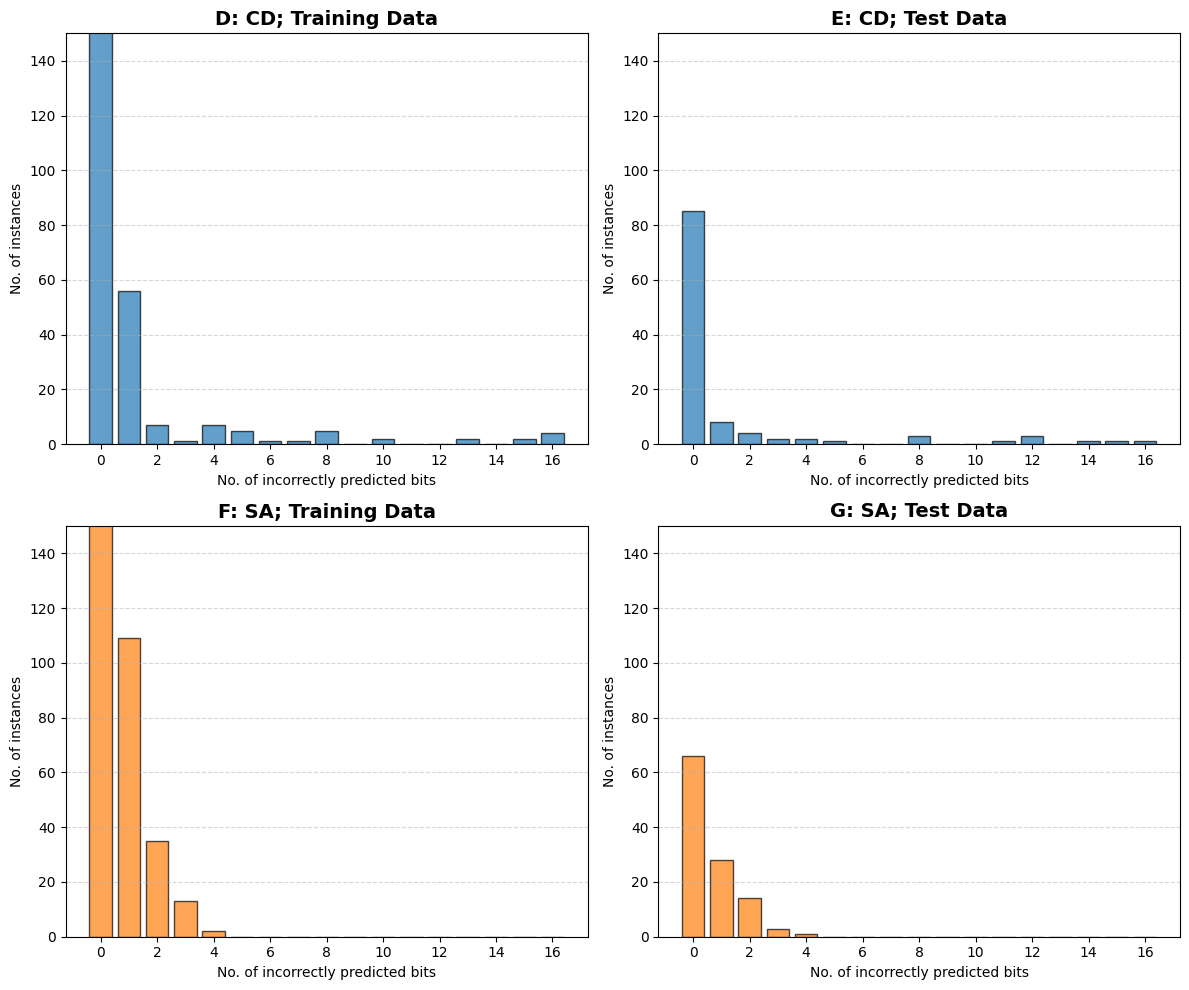

In [ ]:
# 画像の右下4×4(16ビット)に対応するインデックスを配列に加える
mask_indices = []
for r in range(4, 8):
    for c in range(4, 8):
        mask_indices.append(r * 8 + c)

mask_indices = np.array(mask_indices)
mask_indices = mask_indices[mask_indices < 62]

# 誤りビット数の計算
print("Calculating reconstruction errors for CD and SA models...")
# クラスメソッドとして呼び出し
cd_train_errors = rbm_cd.get_incorrect_bits(train_data, mask_indices)
cd_test_errors  = rbm_cd.get_incorrect_bits(test_data, mask_indices)
sa_train_errors = rbm_sa.get_incorrect_bits(train_data, mask_indices)
sa_test_errors  = rbm_sa.get_incorrect_bits(test_data, mask_indices)

# 描写
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

max_bits = len(mask_indices)
bins = np.arange(0, max_bits + 2) - 0.5

def plot_hist(ax, data, title, color):
    ax.hist(data, bins=bins, rwidth=0.8, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("No. of incorrectly predicted bits")
    ax.set_ylabel("No. of instances")
    ax.set_xticks(range(0, max_bits + 1, 2))
    ax.set_ylim(0, 150)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# CD学習RBMの誤りビット数(訓練データ)
plot_hist(axes[0, 0], cd_train_errors, "D: CD; Training Data", 'tab:blue')

# CD学習RBMの誤りビット数(テストデータ)
plot_hist(axes[0, 1], cd_test_errors, "E: CD; Test Data", 'tab:blue')

# SA学習RBMの誤りビット数(訓練データ)
plot_hist(axes[1, 0], sa_train_errors, "F: SA; Training Data", 'tab:orange')

# SA学習RBMの誤りビット数(テストデータ)
plot_hist(axes[1, 1], sa_test_errors, "G: SA; Test Data", 'tab:orange')

plt.tight_layout()
plt.show()

CD-1学習のRBMはデータによっては16ビット間違えることがある一方で、SA学習のRBMは誤りを4ビットまでに抑えられていることがわかります。

### 実験3 対数尤度比較

最後に対数尤度の比較を行います。計算量を減らすため、隠れ層のノード数を20に設定し直します。

In [ ]:
# パラメータ設定
n_visible = 64
n_hidden = 20 # 隠れ層のノードを減らす
epochs = 400
batch_size = 64

# 尤度計算用の全隠れ状態の生成 (2^20通り)
print(f"Generating {1 << n_hidden} hidden states...")
indices = np.arange(1 << n_hidden, dtype=np.uint32)[:, np.newaxis]
bit_masks = 1 << np.arange(n_hidden, dtype=np.uint32)[::-1]
all_hidden_states = (indices & bit_masks > 0).astype(float)
print("Done.")

# 比較用の2つのモデルを初期化
rbm_cd2 = IntegratedRBM(n_visible, n_hidden, learning_rate=0.10)
rbm_sa2 = IntegratedRBM(n_visible, n_hidden, learning_rate=0.10)

# 履歴保存用のリストを追加
ll_history_cd = []
ll_history_sa = []
epoch_list = []

print("Starting Training Comparison...")

for epoch in range(1, epochs + 1):
    np.random.shuffle(train_data)

    # バッチ学習
    for i in range(0, len(train_data), batch_size):
        batch = train_data[i:i+batch_size]

        # それぞれ独立したモデルとして学習
        rbm_cd2.train_step_cd(batch)
        rbm_sa2.train_step_sa(batch, num_reads=batch_size)

    # 10エポックごとに尤度を計算して比較
    if epoch % 10 == 0 or epoch == 1:
        # 両モデルの対数尤度を算出
        ll_cd = rbm_cd2.get_log_likelihood(train_data, all_hidden_states)
        ll_sa = rbm_sa2.get_log_likelihood(train_data, all_hidden_states)

        # データの保存
        epoch_list.append(epoch)
        ll_history_cd.append(ll_cd)
        ll_history_sa.append(ll_sa)

        print(f"Epoch {epoch:3d}: CD LL={ll_cd:.2f}, SA LL={ll_sa:.2f}")

Generating 1048576 hidden states...
Done.
Starting Training Comparison...
Epoch   1: CD LL=-44.46, SA LL=-44.46
Epoch  10: CD LL=-44.29, SA LL=-43.84
Epoch  20: CD LL=-43.86, SA LL=-43.75
Epoch  30: CD LL=-43.08, SA LL=-43.61
Epoch  40: CD LL=-40.78, SA LL=-43.41
Epoch  50: CD LL=-38.06, SA LL=-43.15
Epoch  60: CD LL=-35.56, SA LL=-42.87
Epoch  70: CD LL=-33.28, SA LL=-42.65
Epoch  80: CD LL=-31.34, SA LL=-42.23
Epoch  90: CD LL=-29.88, SA LL=-41.25
Epoch 100: CD LL=-28.43, SA LL=-39.59
Epoch 110: CD LL=-27.32, SA LL=-37.56
Epoch 120: CD LL=-26.05, SA LL=-35.62
Epoch 130: CD LL=-25.18, SA LL=-33.88
Epoch 140: CD LL=-24.65, SA LL=-32.13
Epoch 150: CD LL=-24.12, SA LL=-30.50
Epoch 160: CD LL=-23.09, SA LL=-28.87
Epoch 170: CD LL=-22.83, SA LL=-27.31
Epoch 180: CD LL=-22.27, SA LL=-25.93
Epoch 190: CD LL=-22.00, SA LL=-24.63
Epoch 200: CD LL=-21.69, SA LL=-23.33
Epoch 210: CD LL=-21.57, SA LL=-22.15
Epoch 220: CD LL=-21.88, SA LL=-21.04
Epoch 230: CD LL=-21.23, SA LL=-20.12
Epoch 240: CD 

求めたエポック毎の対数尤度をグラフに描写します。

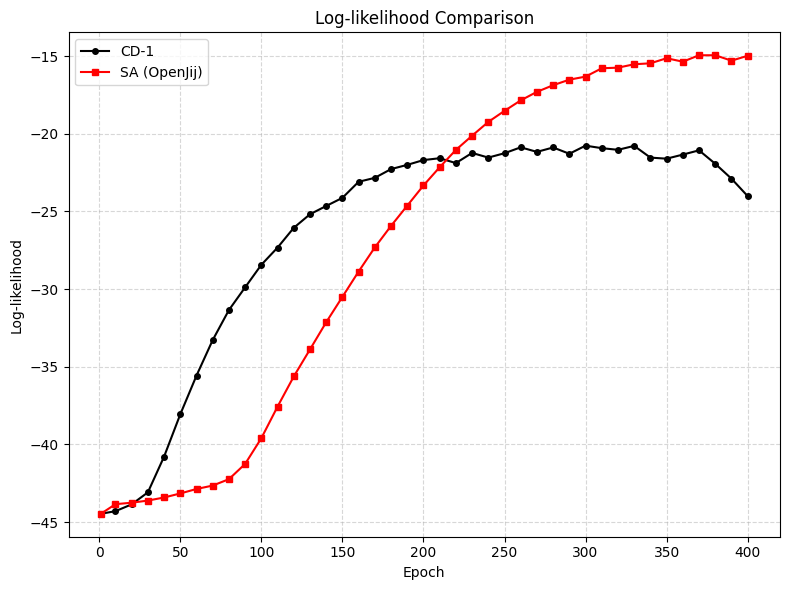

In [ ]:
# 5. 対数尤度の推移を描写

plt.figure(figsize=(8, 6))
plt.plot(epoch_list, ll_history_cd, 'o-', color='black', label='CD-1', markersize=4)
plt.plot(epoch_list, ll_history_sa, 's-', color='red', label='SA (OpenJij)', markersize=4)

plt.xlabel("Epoch")
plt.ylabel("Log-likelihood")
plt.title(f"Log-likelihood Comparison")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

200エポックでCD-1の対数尤度が一定になり、SAはさらに小さくなって400エポックで一定になっています。

## まとめ

本記事では、元論文のCD-1学習のRBMとQA学習のRBMを実装し、BASデータセットの画像分類、画像再構成、対数尤度の比較を行いました。検証した結果、3つの実験において、論文の報告とは異なる結果になりました。原因は、QAの代わりに用いたSAのサンプリング方法にあると思われます。実験結果からQAとSAのサンプリングは異なる振舞いをし、SAによるサンプリングはCD-1よりも真の確率分布を模倣できていると言えます。

## あとがき

RBMの理論を学ぶだけでなく実装にも取り組んだことで、RBMの仕組みについて理解を深めることができました。また、SA学習のRBMはQAとは異なる結果を示したので、QAにより近い振舞いをするシミュレーテッド量子アニーリング(SQA)を使ってRBMを学習した場合と比較してみたいと思いました。